In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

BASE_DIR = Path('..')
PROC_DIR = BASE_DIR / 'data' / 'processed'
FIG_DIR = BASE_DIR / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# load features matrices
morgan = pd.read_csv(PROC_DIR / 'morgan_fingerprints.csv')
consensus = pd.read_csv(PROC_DIR / 'consensus_profiles.csv')
ic50 = pd.read_csv(PROC_DIR / 'gdsc2_ic50_matrix.csv')
gdsc2 = pd.read_csv(PROC_DIR / 'gdsc2_matched.csv')

# extract arrays
morgan_cols = [c for c in morgan.columns if c.startswith('morgan_')]
morpho_cols = [c for c in consensus.columns if not c.startswith('Metadata_') and c != 'drug_name']
drug_names = morgan['drug_name'].tolist()

X_morgan = morgan[morgan_cols].values
X_morpho = consensus.set_index('drug_name').loc[drug_names][morpho_cols].values

print(f"Morgan matrix:    {X_morgan.shape}")
print(f"Morphology matrix:{X_morpho.shape}")
print(f"IC50 matrix:      {ic50.shape}")
print(f"Drug order aligned: {drug_names[:3]}")

Morgan matrix:    (175, 2048)
Morphology matrix:(175, 3178)
IC50 matrix:      (175, 970)
Drug order aligned: ['Gefitinib', 'Vorinostat', 'Nilotinib']


In [4]:
# PCA on Morgan fingerprints

from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

# standardize morphology
scaler = StandardScaler()
X_morpho_scaled = scaler.fit_transform(X_morpho)

# PCA on Morgan
pca_morgan = SklearnPCA(n_components=50, random_state=42)
Z_morgan = pca_morgan.fit_transform(X_morgan)

# PCA on Morphology
pca_morpho = SklearnPCA(n_components=50, random_state=42)
Z_morpho = pca_morpho.fit_transform(X_morpho_scaled)

print("morgan PCA:")
print(f"variance explained (PC1-5): {pca_morgan.explained_variance_ratio_[:5].round(3)}")
print(f"cumulative (50 PCs): {pca_morgan.explained_variance_ratio_.sum():.3f}")

print("\nMorphology PCA:")
print(f"variance explained (PC1-5): {pca_morpho.explained_variance_ratio_[:5].round(3)}")
print(f"cumulative (50 PCs): {pca_morpho.explained_variance_ratio_.sum():.3f}")

morgan PCA:
variance explained (PC1-5): [0.037 0.03  0.028 0.025 0.023]
cumulative (50 PCs): 0.622

Morphology PCA:
variance explained (PC1-5): [0.379 0.162 0.095 0.05  0.042]
cumulative (50 PCs): 0.962


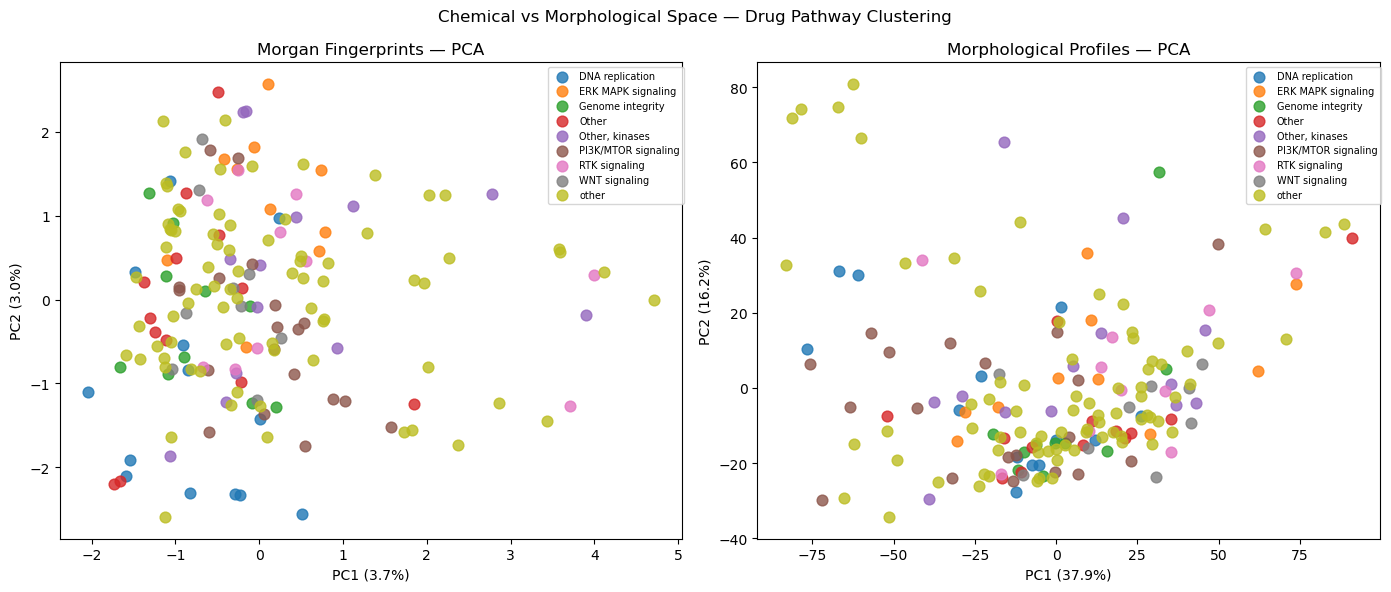

saved: 03_pca_morgan_vs_morphology.png


In [6]:
# visualize PCA space colored by pathway

# get pathway labels for each drug
pathway_map = gdsc2[['DRUG_NAME', 'PATHWAY_NAME']].drop_duplicates()
pathway_map.columns = ['drug_name', 'pathway']
drug_pathway = pd.DataFrame({'drug_name': drug_names}).merge(pathway_map, on='drug_name', how='left')

# keep top 8 pathways for readability, group rest as "other"
top_pathways = drug_pathway['pathway'].value_counts().head(8).index.tolist()
drug_pathway['pathway_plot'] = drug_pathway['pathway'].apply(
    lambda x: x if x in top_pathways else 'other'
)

pathway_labels = drug_pathway['pathway_plot'].tolist()
unique_pathways = sorted(set(pathway_labels))
palette = sns.color_palette('tab10', len(unique_pathways))
color_map = dict(zip(unique_pathways, palette))
colors = [color_map[p] for p in pathway_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Morgan PCA plot
for pathway in unique_pathways:
    idx = [i for i, p in enumerate(pathway_labels) if p == pathway]
    axes[0].scatter(Z_morgan[idx, 0], Z_morgan[idx, 1], 
                   label=pathway, color=color_map[pathway], alpha=0.8, s=60)
axes[0].set_xlabel(f"PC1 ({pca_morgan.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_morgan.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Morgan Fingerprints — PCA")
axes[0].legend(fontsize=7, bbox_to_anchor=(1.01, 1))

# morphology PCA plot
for pathway in unique_pathways:
    idx = [i for i, p in enumerate(pathway_labels) if p == pathway]
    axes[1].scatter(Z_morpho[idx, 0], Z_morpho[idx, 1],
                   label=pathway, color=color_map[pathway], alpha=0.8, s=60)
axes[1].set_xlabel(f"PC1 ({pca_morpho.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_morpho.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Morphological Profiles — PCA")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1))

plt.suptitle("Chemical vs Morphological Space — Drug Pathway Clustering", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_pca_morgan_vs_morphology.png", dpi=150, bbox_inches='tight')
plt.show()
print("saved: 03_pca_morgan_vs_morphology.png")

drug pairs compared: 15,225

spearman correlation between:
  chemical similarity (Tanimoto) vs
  morphological similarity (Cosine):
  r = 0.031, p = 1.52e-04


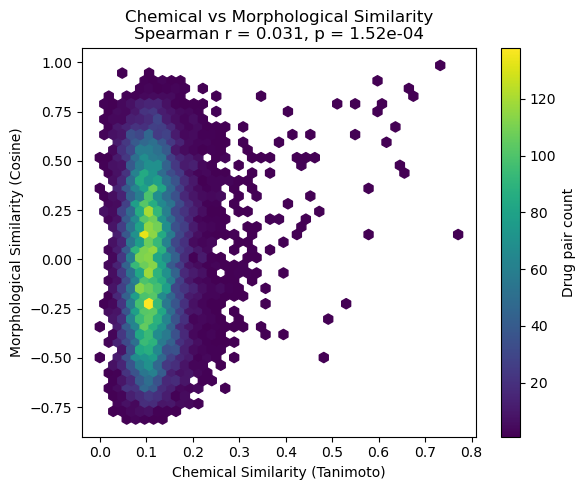

In [7]:
# chemical vs morphological similarity correlation

# pairwise Tanimoto similarity for Morgan (binary fingerprints)
def tanimoto_matrix(X):
    intersection = X @ X.T
    row_sums = X.sum(axis=1)
    union = row_sums[:, None] + row_sums[None, :] - intersection
    return intersection / (union + 1e-10)

# pairwise cosine similarity for morphology
def cosine_matrix(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm = X / (norms + 1e-10)
    return X_norm @ X_norm.T

tanimoto = tanimoto_matrix(X_morgan.astype(float))
cosine   = cosine_matrix(X_morpho_scaled)

# extract upper triangle (excluding diagonal)
idx = np.triu_indices(175, k=1)
tanimoto_flat = tanimoto[idx]
cosine_flat   = cosine[idx]

r, p = spearmanr(tanimoto_flat, cosine_flat)

print(f"drug pairs compared: {len(tanimoto_flat):,}")
print(f"\nspearman correlation between:")
print(f"  chemical similarity (Tanimoto) vs")
print(f"  morphological similarity (Cosine):")
print(f"  r = {r:.3f}, p = {p:.2e}")

# quick scatter
plt.figure(figsize=(6, 5))
plt.hexbin(tanimoto_flat, cosine_flat, gridsize=40, cmap='viridis', mincnt=1)
plt.colorbar(label='Drug pair count')
plt.xlabel("Chemical Similarity (Tanimoto)")
plt.ylabel("Morphological Similarity (Cosine)")
plt.title(f"Chemical vs Morphological Similarity\nSpearman r = {r:.3f}, p = {p:.2e}")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_chemical_vs_morphological_similarity.png", dpi=150)
plt.show()

In [8]:
# identify drug pairs that are chemically similar but morphologically divergent

# find pairs with high chemical similarity but low morphological similarity
threshold_high_chem = 0.4
threshold_low_morpho = 0.1

interesting_pairs = []
for i in range(175):
    for j in range(i+1, 175):
        if tanimoto[i,j] >= threshold_high_chem and cosine[i,j] <= threshold_low_morpho:
            interesting_pairs.append({
                'drug_a': drug_names[i],
                'drug_b': drug_names[j],
                'tanimoto': round(tanimoto[i,j], 3),
                'cosine':   round(cosine[i,j], 3)
            })

pairs_df = pd.DataFrame(interesting_pairs).sort_values('tanimoto', ascending=False)
print(f"Chemically similar but morphologically divergent pairs: {len(pairs_df)}")
print(f"\n{pairs_df.head(10).to_string()}")

Chemically similar but morphologically divergent pairs: 4

        drug_a     drug_b  tanimoto  cosine
3  Ulixertinib     VX-11e     0.531  -0.208
1     ZM447439  Foretinib     0.495  -0.319
0    Gefitinib  Foretinib     0.483  -0.477
2       LCL161    AZD5582     0.402  -0.074


In [12]:
# IC50 profile similarity — how similar are drug sensitivity patterns across cell lines?
ic50_vals = ic50.values.astype(float)  # shape (175, 969)

# Compute cosine similarity on IC50 vectors (treating NaN as 0 for now)
ic50_filled = np.nan_to_num(ic50_vals, nan=0.0)
ic50_sim = cosine_matrix(ic50_filled)

ic50_flat   = ic50_sim[idx]
morpho_flat = cosine_flat

r_morpho_ic50, p_morpho_ic50 = spearmanr(morpho_flat, ic50_flat)
r_chem_ic50,   p_chem_ic50   = spearmanr(tanimoto_flat, ic50_flat)

print(f"Correlation with IC50 profile similarity:")
print(f"  Morphology → IC50: Spearman r = {r_morpho_ic50:.3f}, p = {p_morpho_ic50:.2e}")
print(f"  Chemistry  → IC50: Spearman r = {r_chem_ic50:.3f},  p = {p_chem_ic50:.2e}")
print(f"\nKey question: does morphology correlate better with drug response than chemistry?")

Correlation with IC50 profile similarity:
  Morphology → IC50: Spearman r = 0.039, p = 1.38e-06
  Chemistry  → IC50: Spearman r = -0.002,  p = 7.63e-01

Key question: does morphology correlate better with drug response than chemistry?


In [14]:
# save similarity matrices 

np.save(PROC_DIR / "tanimoto_similarity.npy", tanimoto)
np.save(PROC_DIR / "morpho_cosine_similarity.npy", cosine)
np.save(PROC_DIR / "ic50_cosine_similarity.npy", ic50_sim)

print("saved similarity matrices:")
print(f"tanimoto_similarity.npy     → {tanimoto.shape}")
print(f"morpho_cosine_similarity.npy → {cosine.shape}")
print(f"ic50_cosine_similarity.npy   → {ic50_sim.shape}")

print("\nKey findings:")
print(f"1. chemical vs morphological similarity:  r = 0.031 (orthogonal modalities)")
print(f"2. chemistry  → IC50 similarity:          r = -0.002, p = 0.763 (uninformative)")
print(f"3. morphology → IC50 similarity:          r = 0.039,  p = 1.38e-06 (significant)")

saved similarity matrices:
tanimoto_similarity.npy     → (175, 175)
morpho_cosine_similarity.npy → (175, 175)
ic50_cosine_similarity.npy   → (175, 175)

Key findings:
1. chemical vs morphological similarity:  r = 0.031 (orthogonal modalities)
2. chemistry  → IC50 similarity:          r = -0.002, p = 0.763 (uninformative)
3. morphology → IC50 similarity:          r = 0.039,  p = 1.38e-06 (significant)
